<a href="https://colab.research.google.com/github/yuta1-cell/Rice-Leaf-Health-App/blob/main/rice_disease_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Downloading latest version
path = kagglehub.dataset_download("anshulm257/rice-disease-dataset")

#print("Access to the dataset:", path)

# Setting sizes
batch_size = 32
image_size = (300, 300)

Using Colab cache for faster access to the 'rice-disease-dataset' dataset.


In [2]:
import tensorflow as tf
import os

fixed_path = os.path.join(path, "Rice_Leaf_AUG")

# Training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    fixed_path,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size = image_size,
    batch_size = batch_size
)

# Validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    fixed_path,
    validation_split = 0.2,
    subset = "validation",
    seed = 123,
    image_size = image_size,
    batch_size = batch_size
)

# Class names
class_names = train_ds.class_names
print("Found classes:", class_names)

Found 3829 files belonging to 6 classes.
Using 3064 files for training.
Found 3829 files belonging to 6 classes.
Using 765 files for validation.
Found classes: ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Sheath Blight']


In [3]:
# AUTOTUNE
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [4]:
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

# Data augmentation
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.3),
    tf.keras.layers.RandomContrast(0.3),
])

# Introducing EfficientNet
base_model = EfficientNetB0(
    input_shape=(300,300,3),
    include_top=False,
    weights='imagenet'
)

# Creating models
model = tf.keras.Sequential([
    data_aug,
    tf.keras.layers.Lambda(preprocess_input),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 121s 763ms/step - accuracy: 0.5911 - loss: 1.2791 - val_accuracy: 0.5137 - val_loss: 1.9433 - learning_rate: 0.0010
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 60s 622ms/step - accuracy: 0.7555 - loss: 0.7740 - val_accuracy: 0.6641 - val_loss: 1.8773 - learning_rate: 0.0010
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 60s 623ms/step - accuracy: 0.7800 - loss: 0.6637 - val_accuracy: 0.7529 - val_loss: 0.6892 - learning_rate: 0.0010
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 60s 623ms/step - accuracy: 0.8551 - loss: 0.4297 - val_accuracy: 0.7948 - val_loss: 0.5188 - learning_rate: 0.0010
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 60s 620ms/step - accuracy: 0.8678 - loss: 0.3930 - val_accuracy: 0.8157 - val_loss: 0.5672 - learning_rate: 0.0010
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 60s 621ms/step - accuracy: 0.8965 - loss: 0.3056 - val_accuracy: 0.9294 - val_loss: 0.1954 - learning_rate: 0.0010
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 59s 617ms/step - accuracy: 0.9236 - loss: 0

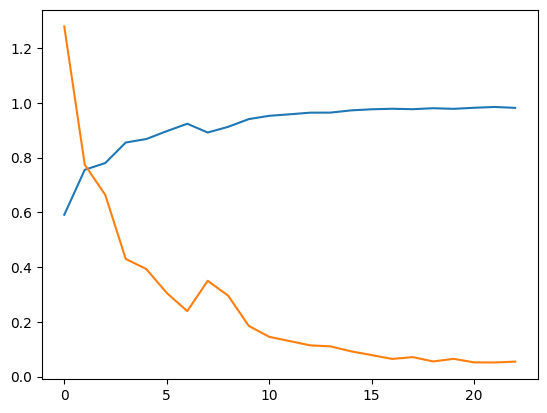

In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2)
]



# Start
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.show()

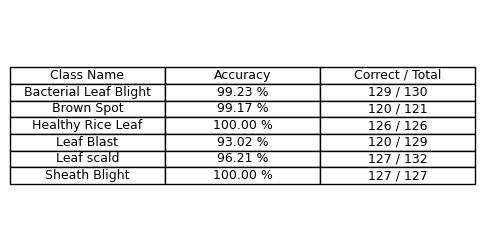

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)


cm_diagonal = cm.diagonal()
cm_sum_per_class = cm.sum(axis=1)
table_data = []

for i, class_name in enumerate(class_names):
    if cm_sum_per_class[i] > 0:
        acc = (cm_diagonal[i] / cm_sum_per_class[i]) * 100
        table_data.append([
            class_name,
            f"{acc:.2f} %",
            f"{cm_diagonal[i]} / {cm_sum_per_class[i]}"
        ])
    else:
        table_data.append([class_name, "0.00 %", "0 / 0"])

fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('off')

col_labels = ["Class Name", "Accuracy", "Correct / Total"]

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)

plt.show()